# 04 – Exploratory Data Analysis (EDA)

## Purpose
This notebook explores the CLEANED (Version 1) FinLora transaction dataset through
visualization, structured as:
- Univariate analysis: the distribution/shape of individual variables
- Bivariate analysis: how individual variables relate to the fraud target
- Multivariate analysis: relationships among multiple variables simultaneously

Unlike 02_data_profiling.ipynb, which focused on identifying data quality issues,
this notebook assumes clean data and focuses on visual pattern discovery to build
intuition ahead of Feature Engineering and Model Development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# A clean, high-end visual theme applied globally for this notebook
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

df = pd.read_csv("../Dataset/cleaned_data/finlora_transactions_cleaned_.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

print("Shape:", df.shape)
df.head()

Shape: (11197, 30)


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,ip_risk_score_was_missing,device_trust_score_was_missing,txn_velocity_1h_was_missing,timestamp_was_missing
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0,0.223,0.0,0,0.0,0,0,0,0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0,0.268,0.0,1,0.0,0,0,0,0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0,0.176,0.0,0,0.0,0,0,0,0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0,0.391,0.0,0,0.0,0,0,0,0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0,0.257,0.0,0,0.0,0,0,0,0,0


### Univariate Analysis

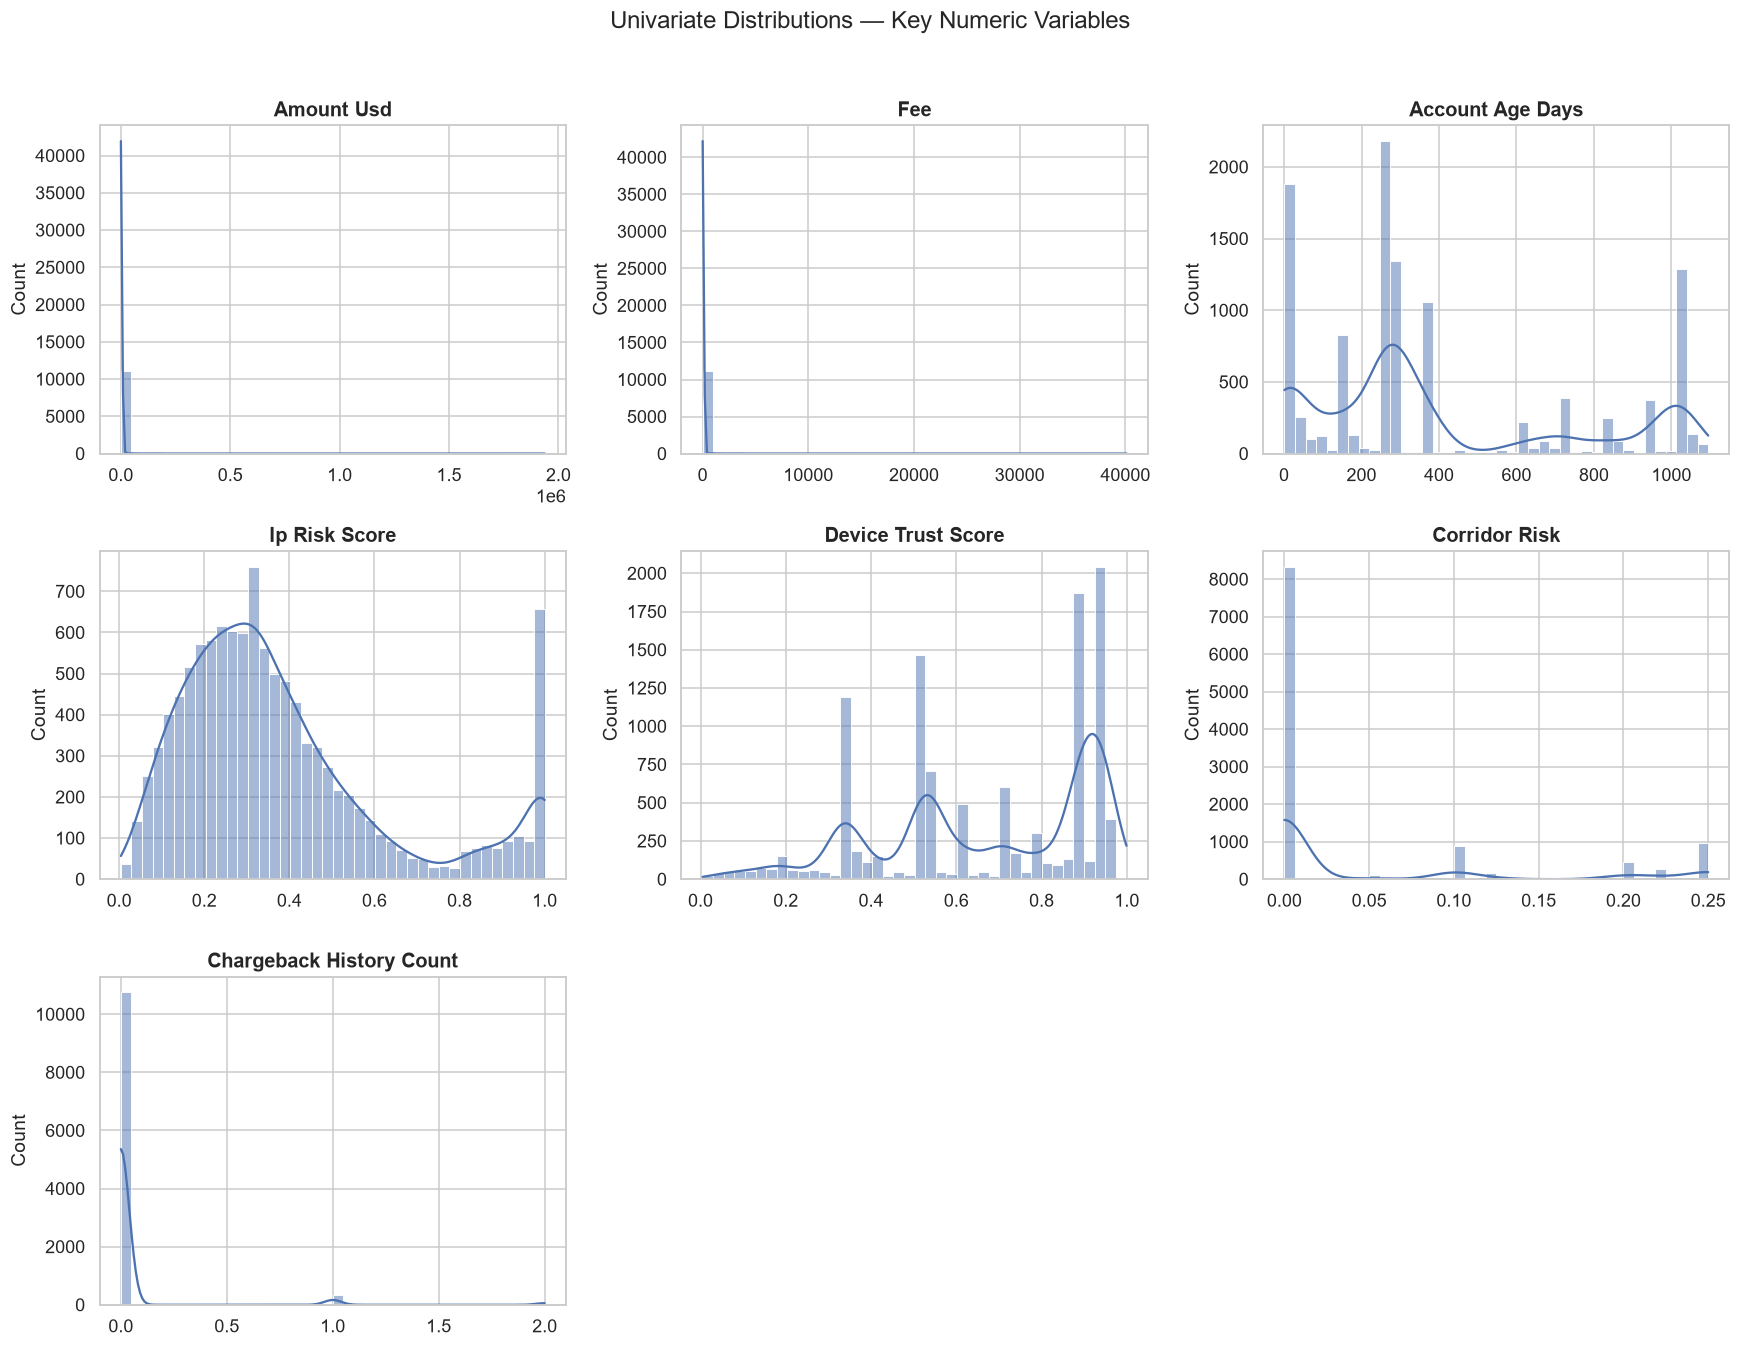

In [2]:
# ------------------------------------------------------------------
# A clean grid of distribution plots for key numeric variables
# ------------------------------------------------------------------
numeric_features = ["amount_usd", "fee", "account_age_days", "ip_risk_score",
                     "device_trust_score", "corridor_risk", "chargeback_history_count"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i], color=sns.color_palette("deep")[0])
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("")

for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Univariate Distributions — Key Numeric Variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\947483453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, ax=axes[i], palette="deep")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\947483453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, ax=axes[i], palette="deep")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\947483453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, ax=axes[i], palette="deep")
C:\Users\HP USER\AppData\

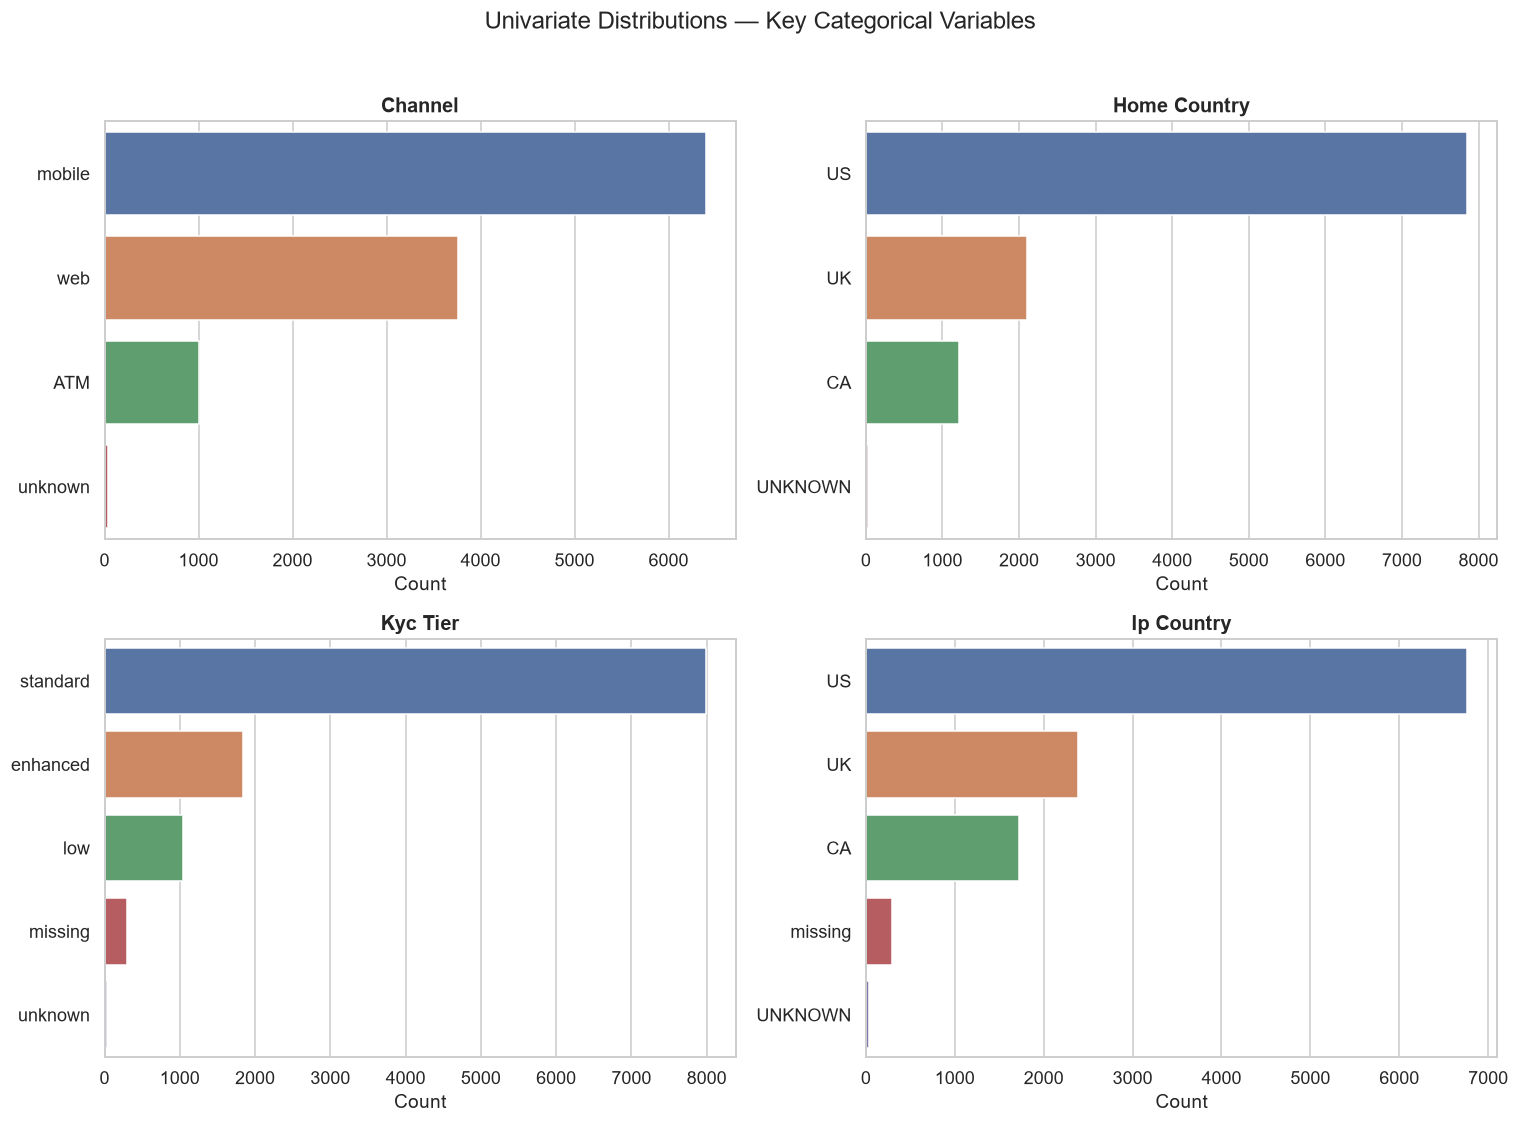

In [3]:
# ------------------------------------------------------------------
# Clean bar charts for the standardized categorical columns
# ------------------------------------------------------------------
categorical_features = ["channel", "home_country", "kyc_tier", "ip_country"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=axes[i], palette="deep")
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

fig.suptitle("Univariate Distributions — Key Categorical Variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\3877463242.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_fraud", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#C44E52"])
C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\3877463242.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_fraud", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#C44E52"])
C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\3877463242.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_fraud", y=col, data=df, ax=axes[i], palette=[

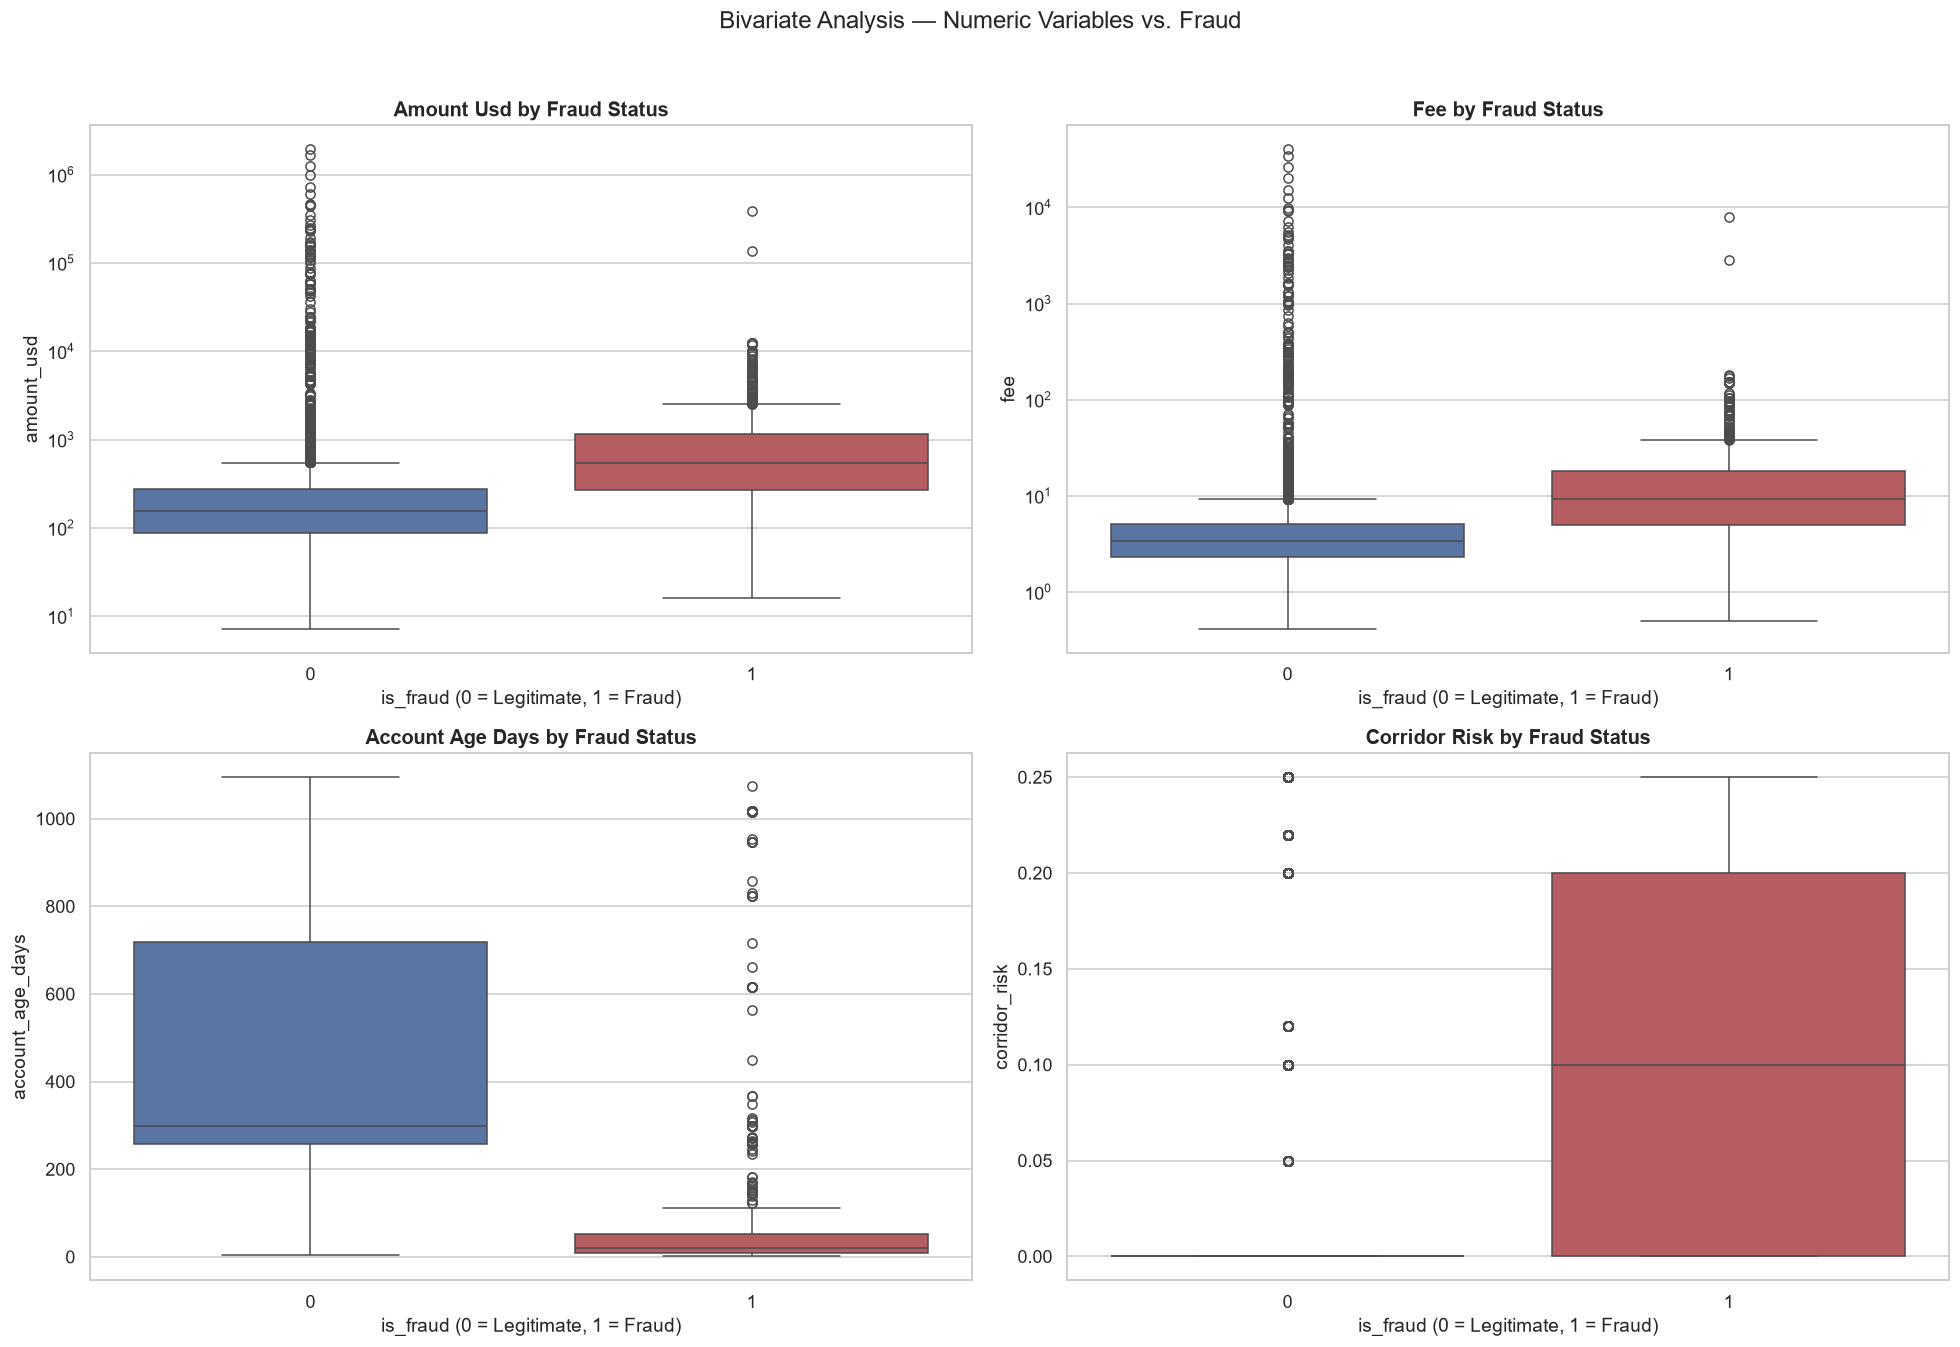

In [9]:
# ------------------------------------------------------------------
# Boxplots comparing key numeric variables across fraud status
# ------------------------------------------------------------------
bivariate_numeric = ["amount_usd", "fee", "account_age_days", "corridor_risk"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(bivariate_numeric):
    sns.boxplot(x="is_fraud", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#C44E52"])
    axes[i].set_title(f"{col.replace('_', ' ').title()} by Fraud Status")
    axes[i].set_xlabel("is_fraud (0 = Legitimate, 1 = Fraud)")
    if col in ["amount_usd", "fee"]:
        axes[i].set_yscale("log")

fig.suptitle("Bivariate Analysis — Numeric Variables vs. Fraud", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Understanding the distribution of fraud vs legitimate transactions

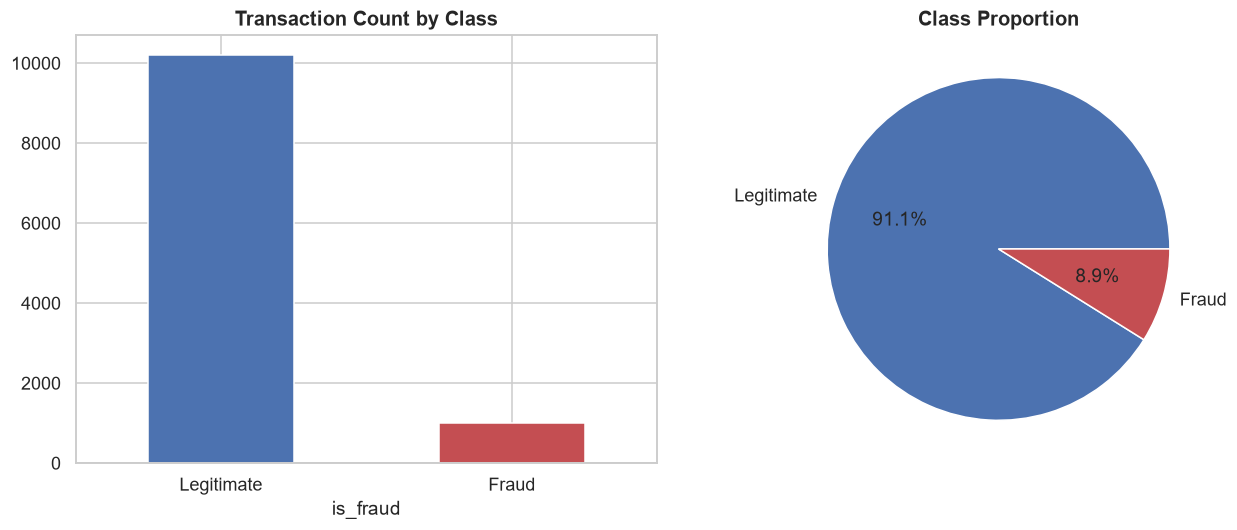

is_fraud
0    91.113691
1     8.886309
Name: proportion, dtype: float64


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

df["is_fraud"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"])
ax[0].set_xticklabels(["Legitimate", "Fraud"], rotation=0)
ax[0].set_title("Transaction Count by Class")

df["is_fraud"].value_counts().plot(kind="pie", ax=ax[1], autopct="%1.1f%%",
                                     labels=["Legitimate", "Fraud"], colors=["#4C72B0", "#C44E52"])
ax[1].set_ylabel("")
ax[1].set_title("Class Proportion")

plt.tight_layout()
plt.show()

print(df["is_fraud"].value_counts(normalize=True) * 100)

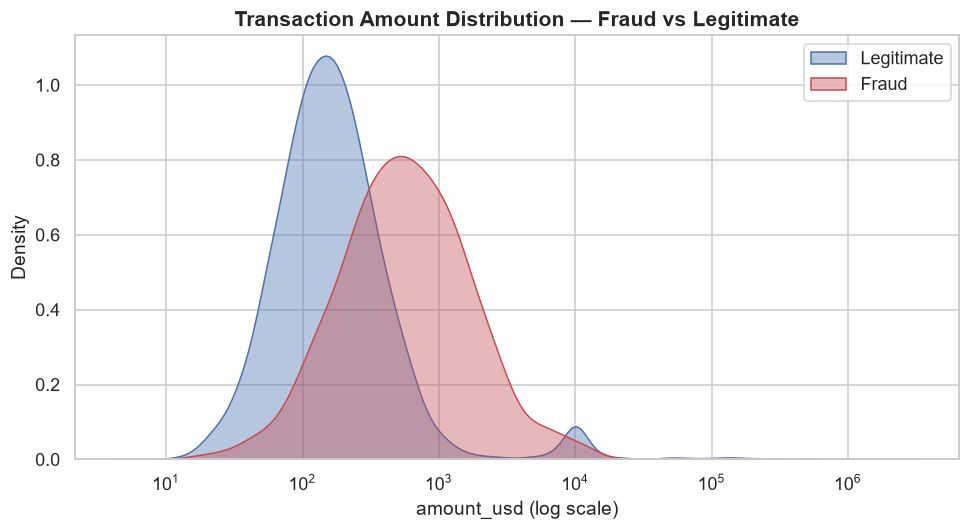

In [5]:
# ------------------------------------------------------------------
# Overlaid density plot: amount_usd distribution, fraud vs legitimate
# ------------------------------------------------------------------
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df[df["is_fraud"] == 0], x="amount_usd", fill=True, alpha=0.4, label="Legitimate", log_scale=True, color="#4C72B0")
sns.kdeplot(data=df[df["is_fraud"] == 1], x="amount_usd", fill=True, alpha=0.4, label="Fraud", log_scale=True, color="#C44E52")
plt.title("Transaction Amount Distribution — Fraud vs Legitimate", fontsize=14)
plt.xlabel("amount_usd (log scale)")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\4084727853.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_rate.values, y=fraud_rate.index, ax=axes[i], palette="rocket")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\4084727853.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_rate.values, y=fraud_rate.index, ax=axes[i], palette="rocket")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\4084727853.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_rate.values, y=fraud_rate.index, ax=axes[i], pale

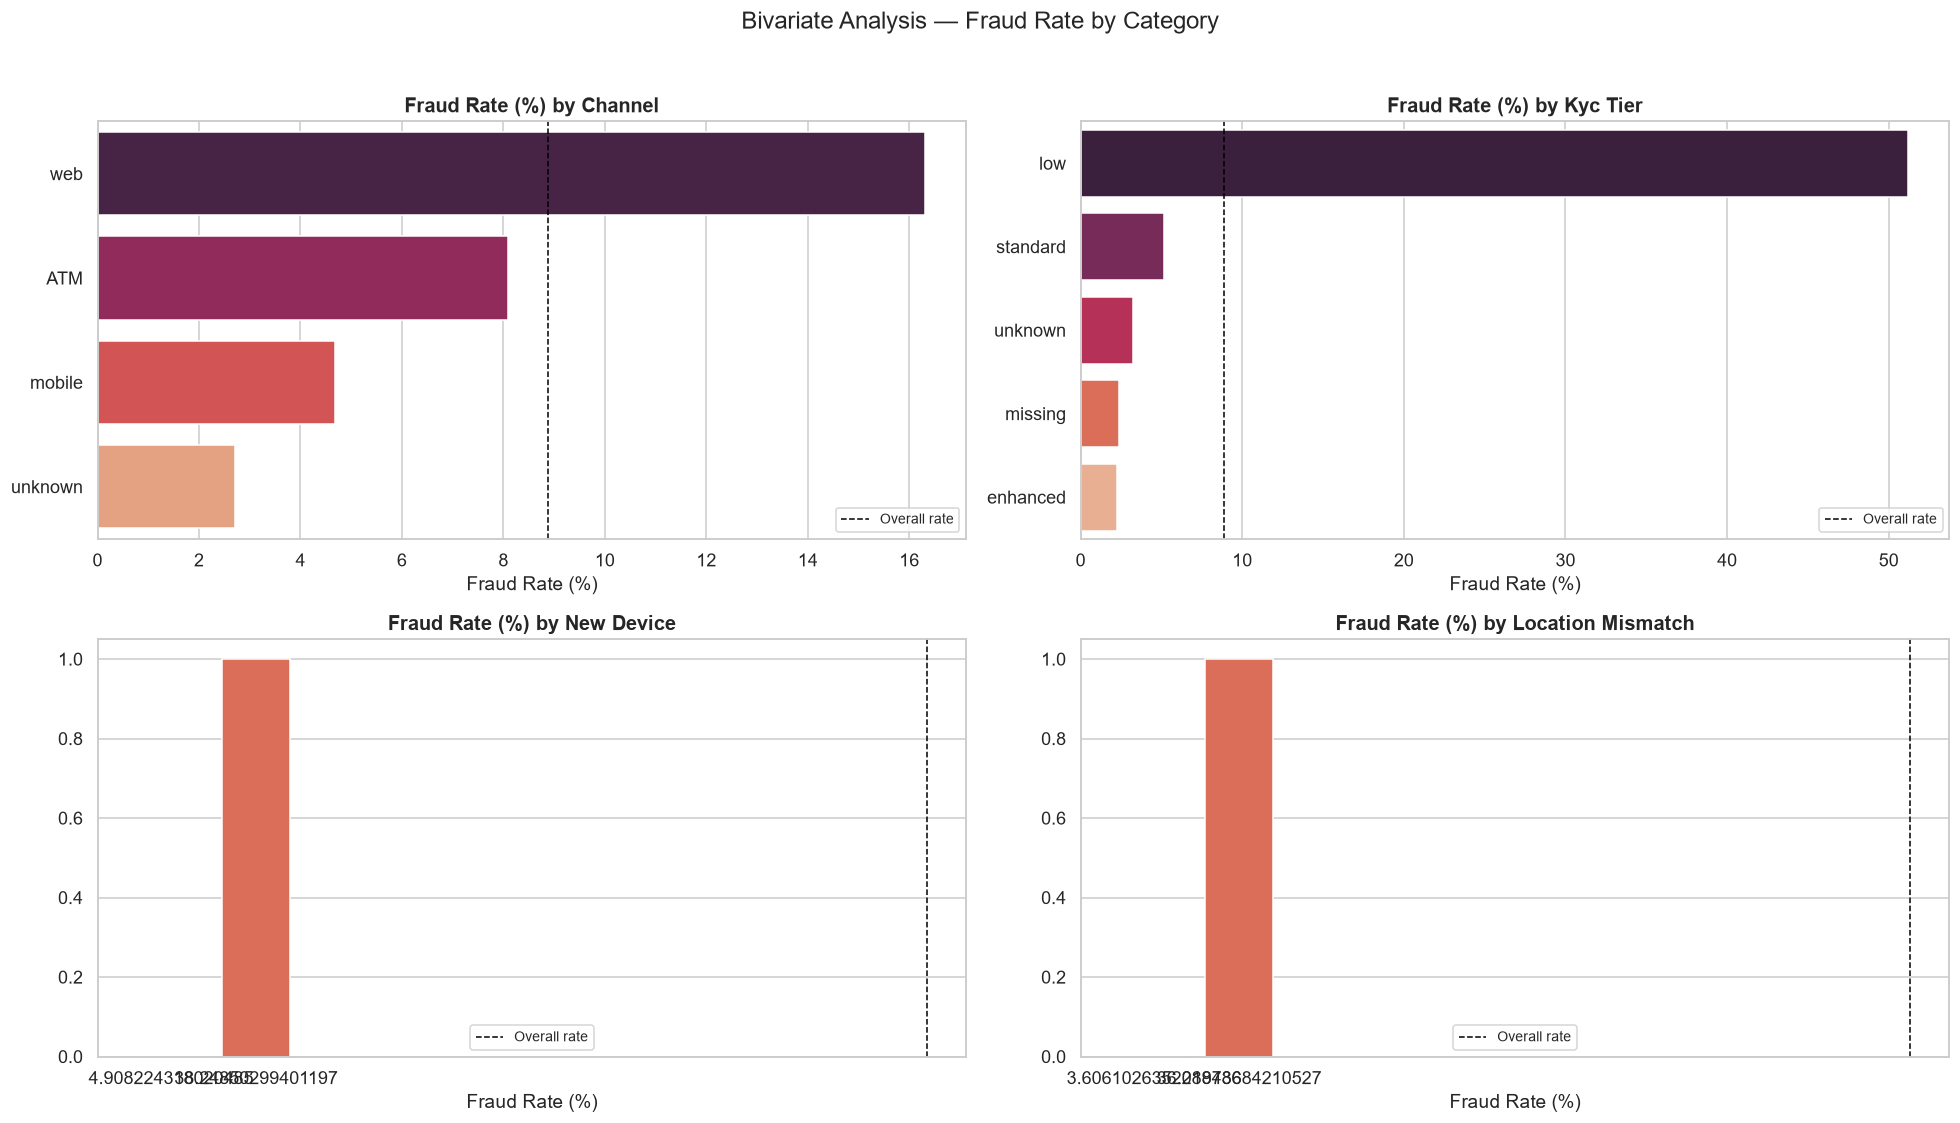

In [8]:
# ------------------------------------------------------------------
# Fraud rate (%) by category, for each key categorical variable
# ------------------------------------------------------------------
categorical_vs_fraud = ["channel", "kyc_tier", "new_device", "location_mismatch"]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_vs_fraud):
    fraud_rate = df.groupby(col)["is_fraud"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=fraud_rate.values, y=fraud_rate.index, ax=axes[i], palette="rocket")
    axes[i].set_title(f"Fraud Rate (%) by {col.replace('_', ' ').title()}")
    axes[i].set_xlabel("Fraud Rate (%)")
    axes[i].set_ylabel("")
    axes[i].axvline(df["is_fraud"].mean() * 100, color="black", linestyle="--", linewidth=1, label="Overall rate")
    axes[i].legend(fontsize=9)

fig.suptitle("Bivariate Analysis — Fraud Rate by Category", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\2643689685.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_rate.index, y=daily_rate.values, ax=axes[1], palette="rocket")


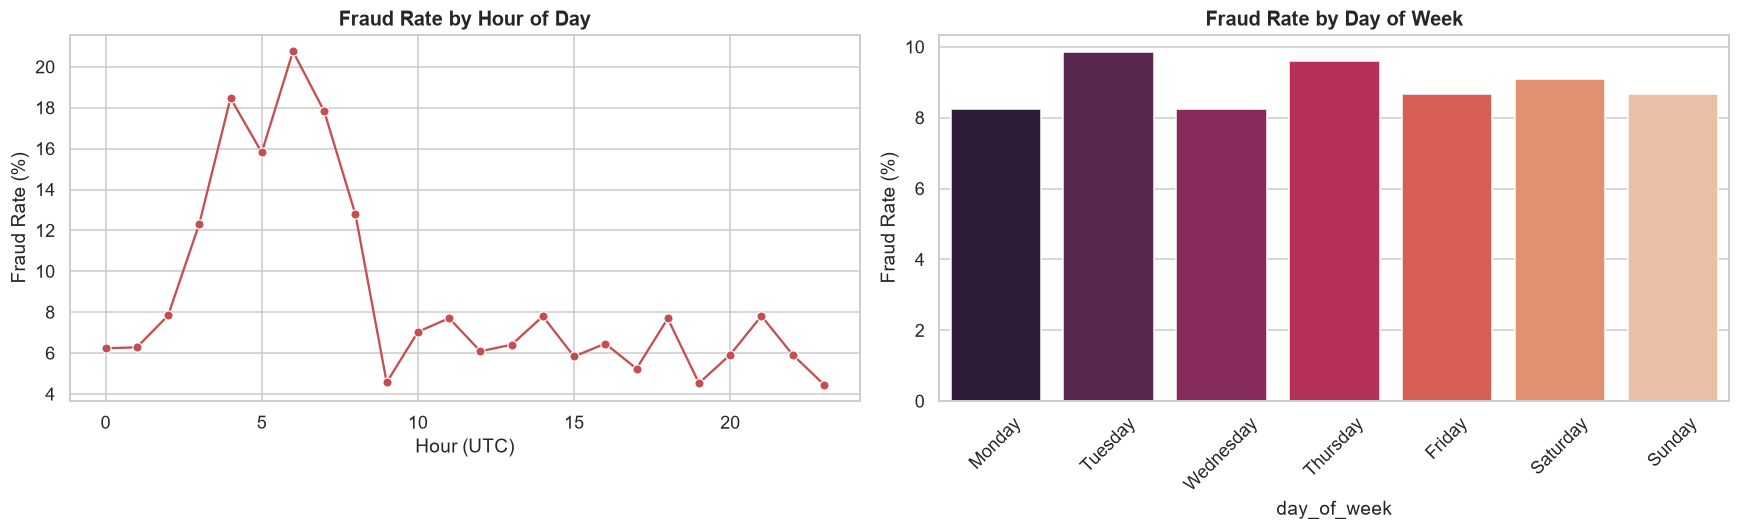

In [7]:
# ------------------------------------------------------------------
# Fraud rate by hour of day and day of week
# ------------------------------------------------------------------
df_time = df.dropna(subset=["timestamp"]).copy()
df_time["hour"] = df_time["timestamp"].dt.hour
df_time["day_of_week"] = df_time["timestamp"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly_rate = df_time.groupby("hour")["is_fraud"].mean() * 100
sns.lineplot(x=hourly_rate.index, y=hourly_rate.values, marker="o", ax=axes[0], color="#C44E52")
axes[0].set_title("Fraud Rate by Hour of Day")
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("Fraud Rate (%)")

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_rate = df_time.groupby("day_of_week")["is_fraud"].mean().reindex(day_order) * 100
sns.barplot(x=daily_rate.index, y=daily_rate.values, ax=axes[1], palette="rocket")
axes[1].set_title("Fraud Rate by Day of Week")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Transactions per customer - distribution and relationship to fraud

C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\3264831223.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_freq.index, y=fraud_by_freq.values, ax=ax[1], palette=["#C44E52", "#4C72B0"])


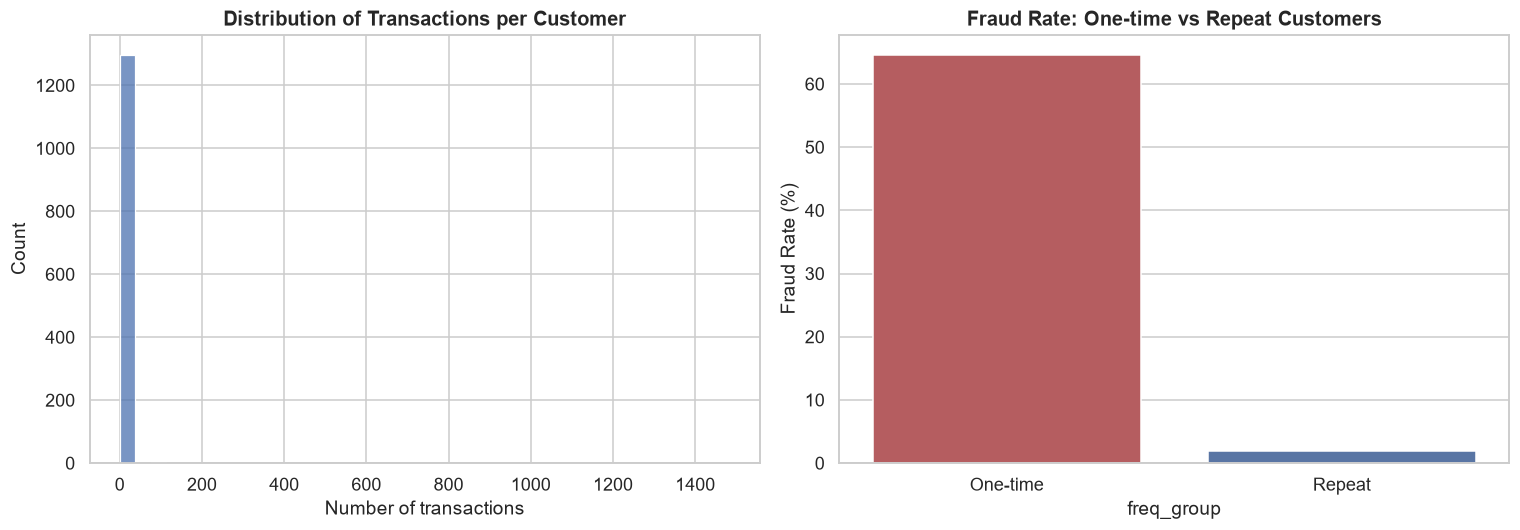

In [12]:
# ------------------------------------------------------------------
# Transactions per customer - distribution and relationship to fraud
# ------------------------------------------------------------------
txn_freq = df.groupby("customer_id").size()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(txn_freq, bins=40, ax=ax[0], color="#4C72B0")
ax[0].set_title("Distribution of Transactions per Customer")
ax[0].set_xlabel("Number of transactions")

df["customer_txn_count"] = df["customer_id"].map(txn_freq)
df["freq_group"] = np.where(df["customer_txn_count"] == 1, "One-time", "Repeat")

fraud_by_freq = df.groupby("freq_group")["is_fraud"].mean() * 100
sns.barplot(x=fraud_by_freq.index, y=fraud_by_freq.values, ax=ax[1], palette=["#C44E52", "#4C72B0"])
ax[1].set_title("Fraud Rate: One-time vs Repeat Customers")
ax[1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

### Customer Characteristics that are asscociated with Fraud

C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\1918840359.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_fraud", y="account_age_days", data=df, ax=axes[0], palette=["#4C72B0", "#C44E52"])
C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\1918840359.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kyc_fraud.values, y=kyc_fraud.index, ax=axes[1], palette="rocket")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\1918840359.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_fraud", y="chargeback_history_count",

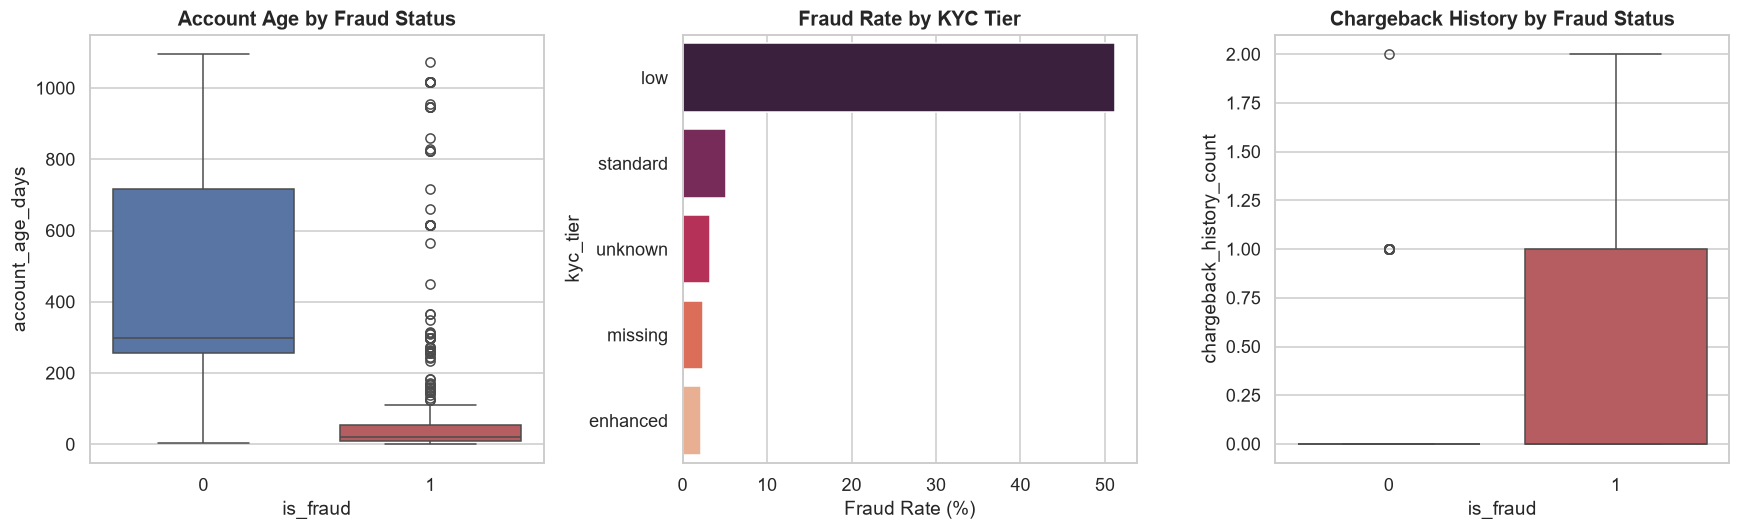

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x="is_fraud", y="account_age_days", data=df, ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Account Age by Fraud Status")

kyc_fraud = df.groupby("kyc_tier")["is_fraud"].mean().sort_values(ascending=False) * 100
sns.barplot(x=kyc_fraud.values, y=kyc_fraud.index, ax=axes[1], palette="rocket")
axes[1].set_title("Fraud Rate by KYC Tier")
axes[1].set_xlabel("Fraud Rate (%)")

sns.boxplot(x="is_fraud", y="chargeback_history_count", data=df, ax=axes[2], palette=["#4C72B0", "#C44E52"])
axes[2].set_title("Chargeback History by Fraud Status")

plt.tight_layout()
plt.show()

## Geographic transaction patterns

C:\Users\HP USER\AppData\Local\Temp\ipykernel_44384\402334281.py:111: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
c:\My portfolio\Projects\Python\Machine Learning\Detection_of_Fraudulent_Transaction_for_Finlora\finlora_env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


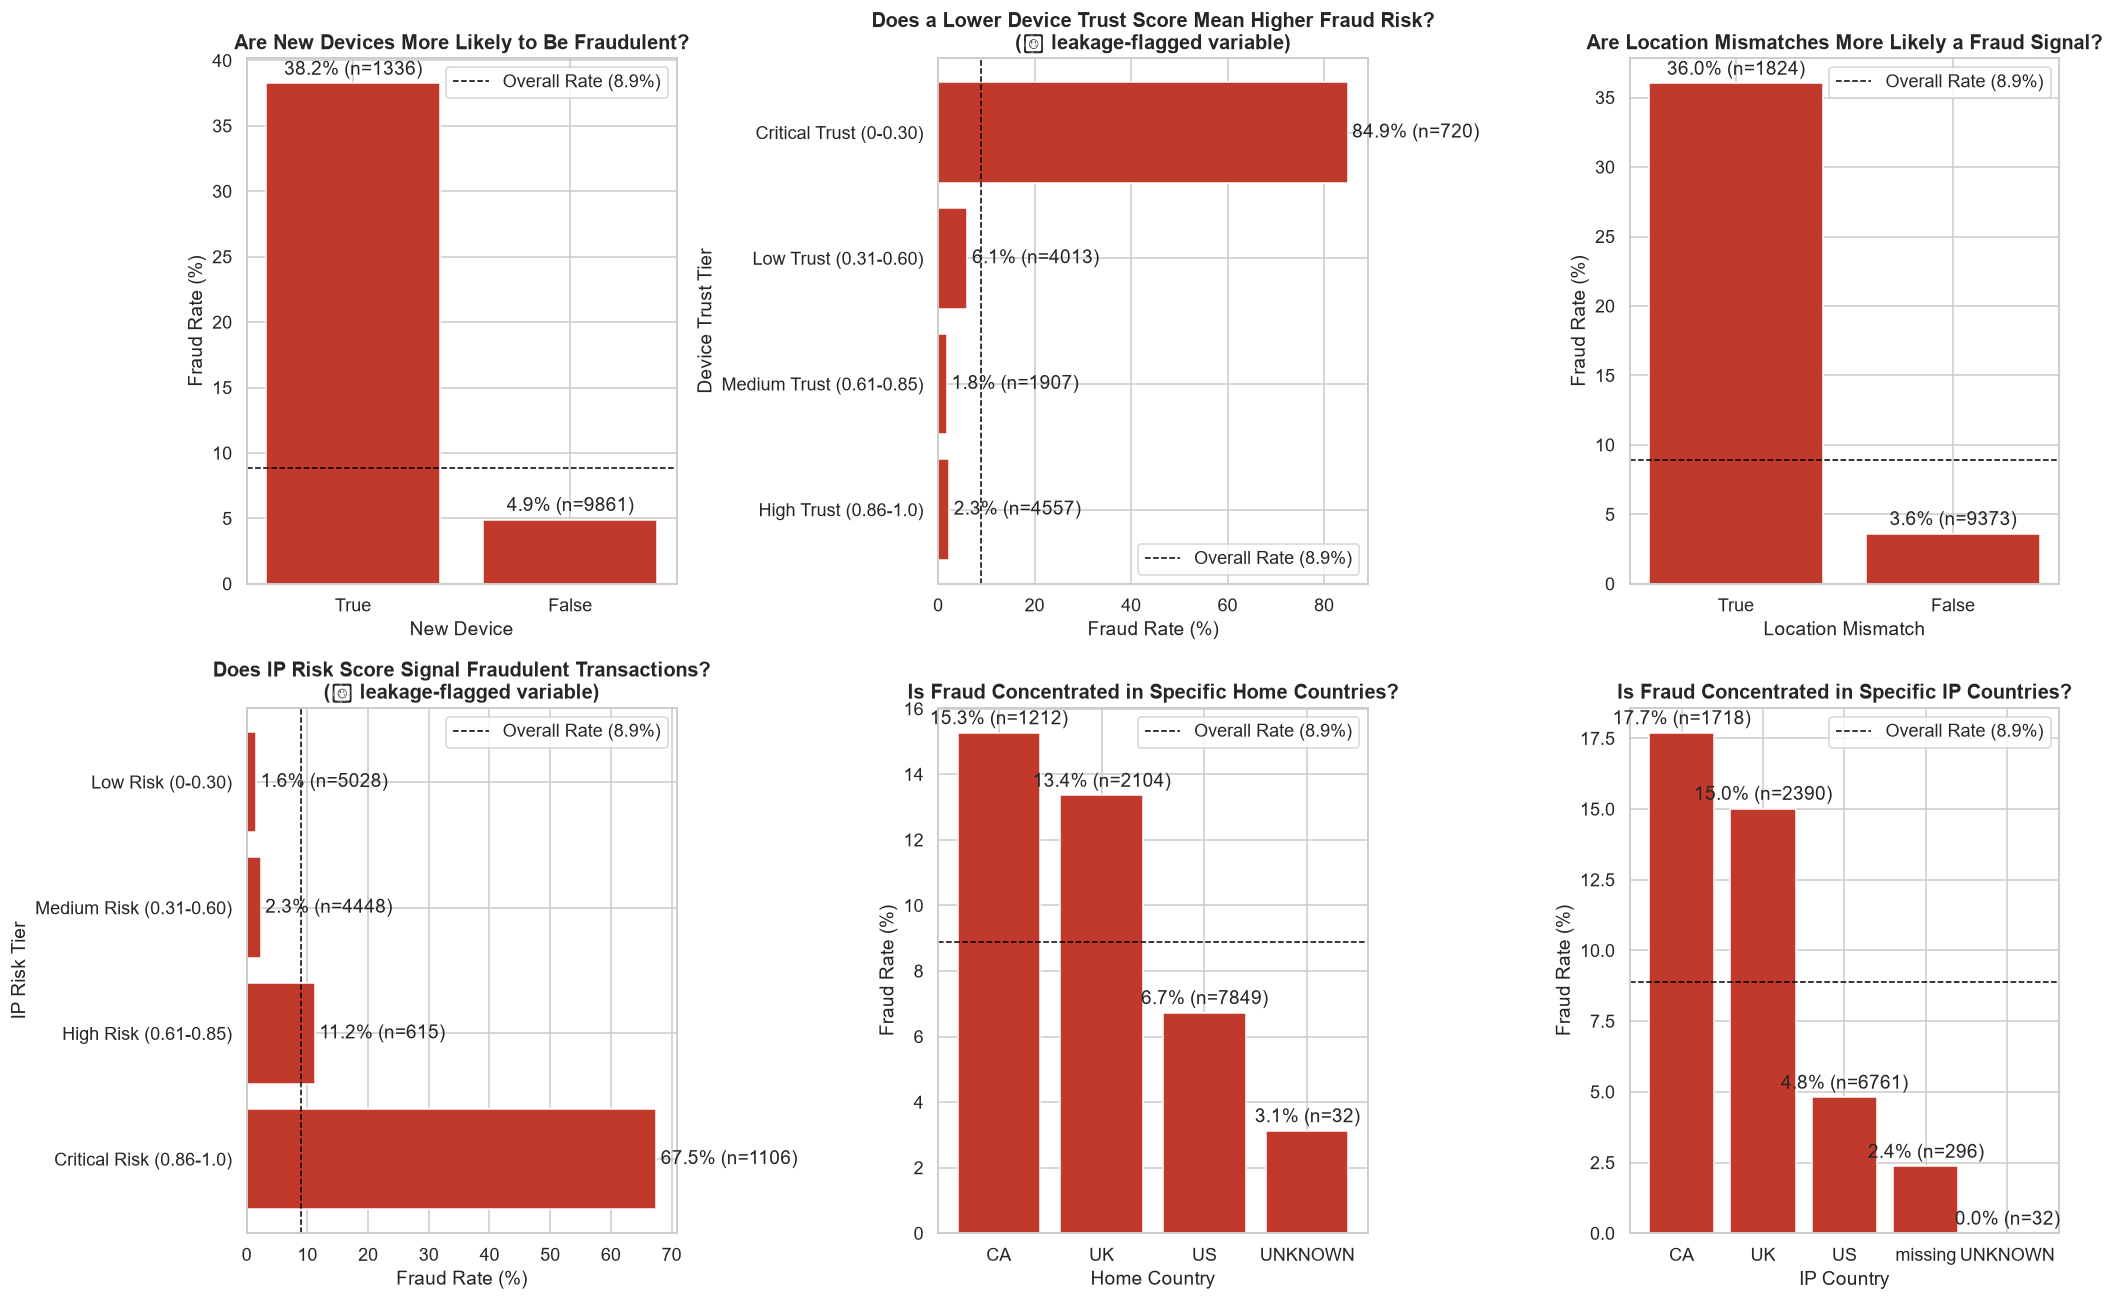

In [17]:
# ------------------------------------------------------------------
# Setup: define overall_rate and standardize the working dataframe name
# ------------------------------------------------------------------
overall_rate = df["is_fraud"].mean() * 100
df_cleaned_transaction_data = df  # alias for consistency with this block

def fraud_rate_by_category(df, category_col, top_n=None):
    grouped = df.groupby(category_col, observed=False)["is_fraud"].agg(["mean", "count"])
    grouped["fraud_rate_pct"] = grouped["mean"] * 100
    grouped = grouped.sort_values("fraud_rate_pct", ascending=False)
    if top_n:
        grouped = grouped.head(top_n)
    return grouped

# 4-tier fraud-risk convention, used to make continuous risk scores
# more legible as fraud-rate comparisons
risk_bins = [0, 0.30, 0.60, 0.85, 1.0]

df_cleaned_transaction_data["ip_risk_tier"] = pd.cut(
    df_cleaned_transaction_data["ip_risk_score"],
    bins=risk_bins,
    labels=["Low Risk (0-0.30)", "Medium Risk (0.31-0.60)", "High Risk (0.61-0.85)", "Critical Risk (0.86-1.0)"],
    include_lowest=True
)

# Note: device_trust_score is inverted - LOW trust = HIGH risk
df_cleaned_transaction_data["device_trust_tier"] = pd.cut(
    df_cleaned_transaction_data["device_trust_score"],
    bins=risk_bins,
    labels=["Critical Trust (0-0.30)", "Low Trust (0.31-0.60)", "Medium Trust (0.61-0.85)", "High Trust (0.86-1.0)"],
    include_lowest=True
)

fig, axes = plt.subplots(2, 3, figsize=(19, 12))
axes = axes.flatten()

# Q1: Are transactions from new devices more likely to be fraudulent?
new_device_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "new_device")
bars = axes[0].bar(new_device_fraud.index.astype(str), new_device_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(new_device_fraud["fraud_rate_pct"], new_device_fraud["count"])]
axes[0].bar_label(bars, labels=labels, padding=3)
axes[0].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[0].set_title("Are New Devices More Likely to Be Fraudulent?")
axes[0].set_xlabel("New Device")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].legend()

# Q2: Does a lower device trust score correlate with fraud?
# CAUTION: device_trust_score is flagged as high-risk for data leakage
# (Data Cleaning found its variation pattern is inconsistent with
# genuine device-level scoring). Interpret this chart as exploratory
# only, not confirmed safe signal.
trust_order = ["Critical Trust (0-0.30)", "Low Trust (0.31-0.60)", "Medium Trust (0.61-0.85)", "High Trust (0.86-1.0)"]
trust_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "device_trust_tier").reindex(trust_order)
bars = axes[1].barh(trust_fraud.index[::-1], trust_fraud["fraud_rate_pct"][::-1], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(trust_fraud["fraud_rate_pct"][::-1], trust_fraud["count"][::-1])]
axes[1].bar_label(bars, labels=labels, padding=3)
axes[1].axvline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[1].set_title("Does a Lower Device Trust Score Mean Higher Fraud Risk?\n(⚠ leakage-flagged variable)")
axes[1].set_xlabel("Fraud Rate (%)")
axes[1].set_ylabel("Device Trust Tier")
axes[1].legend()

# Q3: Are transactions with a location mismatch more likely to be fraud?
mismatch_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "location_mismatch")
bars = axes[2].bar(mismatch_fraud.index.astype(str), mismatch_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(mismatch_fraud["fraud_rate_pct"], mismatch_fraud["count"])]
axes[2].bar_label(bars, labels=labels, padding=3)
axes[2].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[2].set_title("Are Location Mismatches More Likely a Fraud Signal?")
axes[2].set_xlabel("Location Mismatch")
axes[2].set_ylabel("Fraud Rate (%)")
axes[2].legend()

# Q4: Does IP risk score meaningfully separate fraud from legitimate transactions?
# CAUTION: ip_risk_score is also flagged as high-risk for data leakage
# (Data Profiling, Section 11.2 - 0.52 correlation, unclear provenance).
risk_order = ["Low Risk (0-0.30)", "Medium Risk (0.31-0.60)", "High Risk (0.61-0.85)", "Critical Risk (0.86-1.0)"]
ip_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "ip_risk_tier").reindex(risk_order)
bars = axes[3].barh(ip_fraud.index[::-1], ip_fraud["fraud_rate_pct"][::-1], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(ip_fraud["fraud_rate_pct"][::-1], ip_fraud["count"][::-1])]
axes[3].bar_label(bars, labels=labels, padding=3)
axes[3].axvline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[3].set_title("Does IP Risk Score Signal Fraudulent Transactions?\n(⚠ leakage-flagged variable)")
axes[3].set_xlabel("Fraud Rate (%)")
axes[3].set_ylabel("IP Risk Tier")
axes[3].legend()

# Q5: Is fraud concentrated in specific home countries?
home_country_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "home_country")
bars = axes[4].bar(home_country_fraud.index, home_country_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(home_country_fraud["fraud_rate_pct"], home_country_fraud["count"])]
axes[4].bar_label(bars, labels=labels, padding=3)
axes[4].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[4].set_title("Is Fraud Concentrated in Specific Home Countries?")
axes[4].set_xlabel("Home Country")
axes[4].set_ylabel("Fraud Rate (%)")
axes[4].legend()

# Q6: Is fraud concentrated in specific IP countries?
ip_country_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "ip_country")
bars = axes[5].bar(ip_country_fraud.index, ip_country_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(ip_country_fraud["fraud_rate_pct"], ip_country_fraud["count"])]
axes[5].bar_label(bars, labels=labels, padding=3)
axes[5].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[5].set_title("Is Fraud Concentrated in Specific IP Countries?")
axes[5].set_xlabel("IP Country")
axes[5].set_ylabel("Fraud Rate (%)")
axes[5].legend()

plt.tight_layout()
plt.show()

### 
Q1 — New devices: Transactions from new devices show a 38.2% fraud rate (n=1,336) versus 4.9% for known devices (n=9,861) — roughly 7.8x higher. 
    This is one of the strongest, most usable signals found in this entire project.
     Unlike the risk-score variables, new_device is a simple boolean with a clear, plausible mechanism (unfamiliar device = higher fraud risk), and no leakage concern has been raised against it. 
     Strong feature engineering candidate

Q2 — Device trust score (⚠ leakage-flagged): The relationship is dramatic — fraud rate climbs from 1.8–2.3% in the Medium/High trust tiers to 84.9% (n=720) in the Critical Trust tier. This is an extremely strong separation — arguably too strong to be a naturally occurring, honest predictor, which reinforces rather than eases our existing concern. Recall Data Cleaning found this variable's "trust score" jumps by an identical, suspicious 0.15 with no discernible business logic. An 84.9% fraud rate within one tier is the kind of near-deterministic relationship that's consistent with a variable partially derived from the outcome it's supposed to predict. This chart should not be read as "we found a great predictor" — it should be read as further evidence this variable needs provenance resolution before any use in modelling.

Section 9 — Geographic Transaction Patterns: Findings

Q3 — Location mismatch: A clear, strong, and plausible signal — 36.0% fraud rate when there's a mismatch (n=1,824) vs. 3.6% when there isn't (n=9,373), a 10x difference. This is one of the "Tier 2" moderate-but-honest correlations flagged in Data Profiling (0.417), now visually confirmed as a genuinely large, sensible effect. Strong feature engineering candidate.

Q4 — IP risk score (⚠ leakage-flagged): Same pattern as device trust score — climbs from ~1.6–2.3% in Low/Medium tiers to 67.5% (n=1,106) in Critical Risk. Again, a separation this stark is a red flag rather than reassurance, consistent with Data Profiling's leakage concern (0.52 correlation, unclear provenance). Same caveat as Q2 applies.

Q5 — Home country: Fraud rate varies meaningfully by country: CA 15.3%, UK 13.4%, US 6.7%, and a small UNKNOWN group at 3.1% (n=32, too small to draw a firm conclusion from). This is a real, moderate geographic pattern — worth carrying into Feature Engineering, though the mechanism (why CA/UK show higher rates than US) isn't something we can explain from this data alone, and shouldn't be speculated about further than the observation itself.

Q6 — IP country: Similar pattern — CA 17.7%, UK 15.0%, US 4.8%, with the missing category at 2.4% (n=296) and UNKNOWN at 0.0% (n=32, negligible sample size). Notably, ip_country's missing category shows a fraud rate below baseline — consistent with our Data Cleaning finding that this missingness pattern isn't fraud-related. Worth flagging that home_country and ip_country show a very similar per-country ranking (CA > UK > US in both) — this is worth checking for multicollinearity in the multivariate section, since these two variables may be capturing overlapping information rather than independent signal.


### Unusual or suspicious transaction behaviour

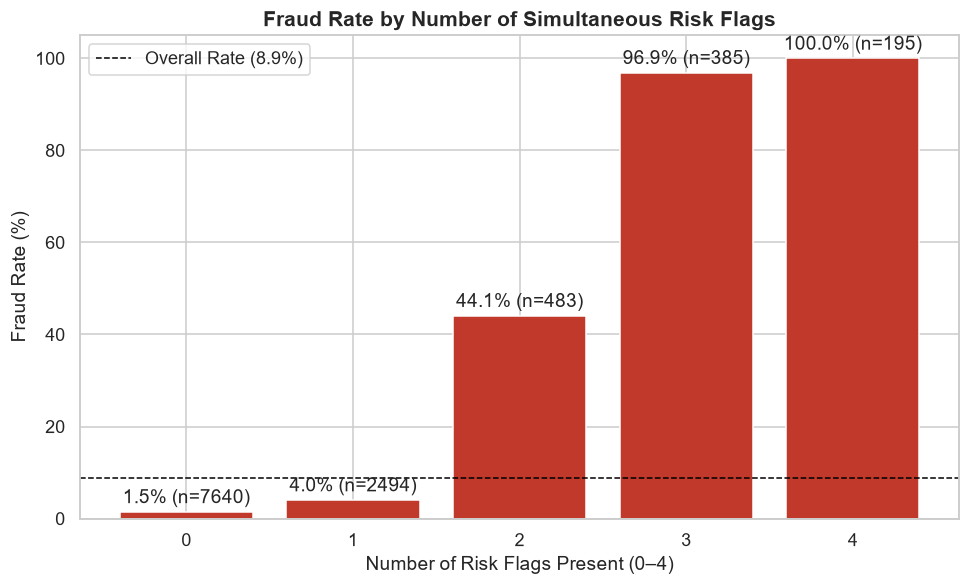

In [18]:
# ------------------------------------------------------------------
# Build a composite "risk flag" count per transaction
# ------------------------------------------------------------------
# We combine several INDEPENDENTLY plausible (non-leakage-flagged)
# signals identified so far: new_device, location_mismatch, and
# unusually high amount/velocity relative to the rest of the dataset.
# ip_risk_score and device_trust_score are DELIBERATELY excluded from
# this composite, since including leakage-flagged variables would
# make the resulting "risk score" untrustworthy for the same reason.

df["flag_new_device"] = df["new_device"].astype(int)
df["flag_location_mismatch"] = df["location_mismatch"].astype(int)
df["flag_high_amount"] = (df["amount_usd"] > df["amount_usd"].quantile(0.90)).astype(int)
df["flag_high_velocity_24h"] = (df["txn_velocity_24h"] > df["txn_velocity_24h"].quantile(0.90)).astype(int)

df["risk_flag_count"] = (
    df["flag_new_device"] + df["flag_location_mismatch"] +
    df["flag_high_amount"] + df["flag_high_velocity_24h"]
)

flag_summary = df.groupby("risk_flag_count")["is_fraud"].agg(["mean", "count"])
flag_summary["fraud_rate_pct"] = flag_summary["mean"] * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(flag_summary.index.astype(str), flag_summary["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(flag_summary["fraud_rate_pct"], flag_summary["count"])]
ax.bar_label(bars, labels=labels, padding=3)
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
ax.set_title("Fraud Rate by Number of Simultaneous Risk Flags", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Risk Flags Present (0–4)")
ax.set_ylabel("Fraud Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# ------------------------------------------------------------------
# Zoom in: the specific combination of high velocity AND high amount
# ------------------------------------------------------------------
high_velocity = df["txn_velocity_1h"] > df["txn_velocity_1h"].quantile(0.95)
high_amount = df["amount_usd"] > df["amount_usd"].quantile(0.95)

combo_labels = ["Neither", "High Amount Only", "High Velocity Only", "Both"]
combo_group = np.select(
    [(~high_velocity & ~high_amount), (~high_velocity & high_amount), (high_velocity & ~high_amount), (high_velocity & high_amount)],
    combo_labels
)
df["velocity_amount_combo"] = combo_group

combo_fraud = df.groupby("velocity_amount_combo")["is_fraud"].agg(["mean", "count"]).reindex(combo_labels)
combo_fraud["fraud_rate_pct"] = combo_fraud["mean"] * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(combo_fraud.index, combo_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(combo_fraud["fraud_rate_pct"], combo_fraud["count"])]
ax.bar_label(bars, labels=labels, padding=3)
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
ax.set_title("Fraud Rate: High Transaction Velocity vs. High Amount (Top 5% each)", fontsize=14, fontweight="bold")
ax.set_ylabel("Fraud Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyLongDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>)

### Multivariate Analysis
Univariate and bivariate views show how single variables relate to fraud in
isolation. This section looks at multiple variables TOGETHER, to check for
overlapping signal (multicollinearity) and to see how combinations of
variables jointly relate to fraud - closer to how a real model will use them.

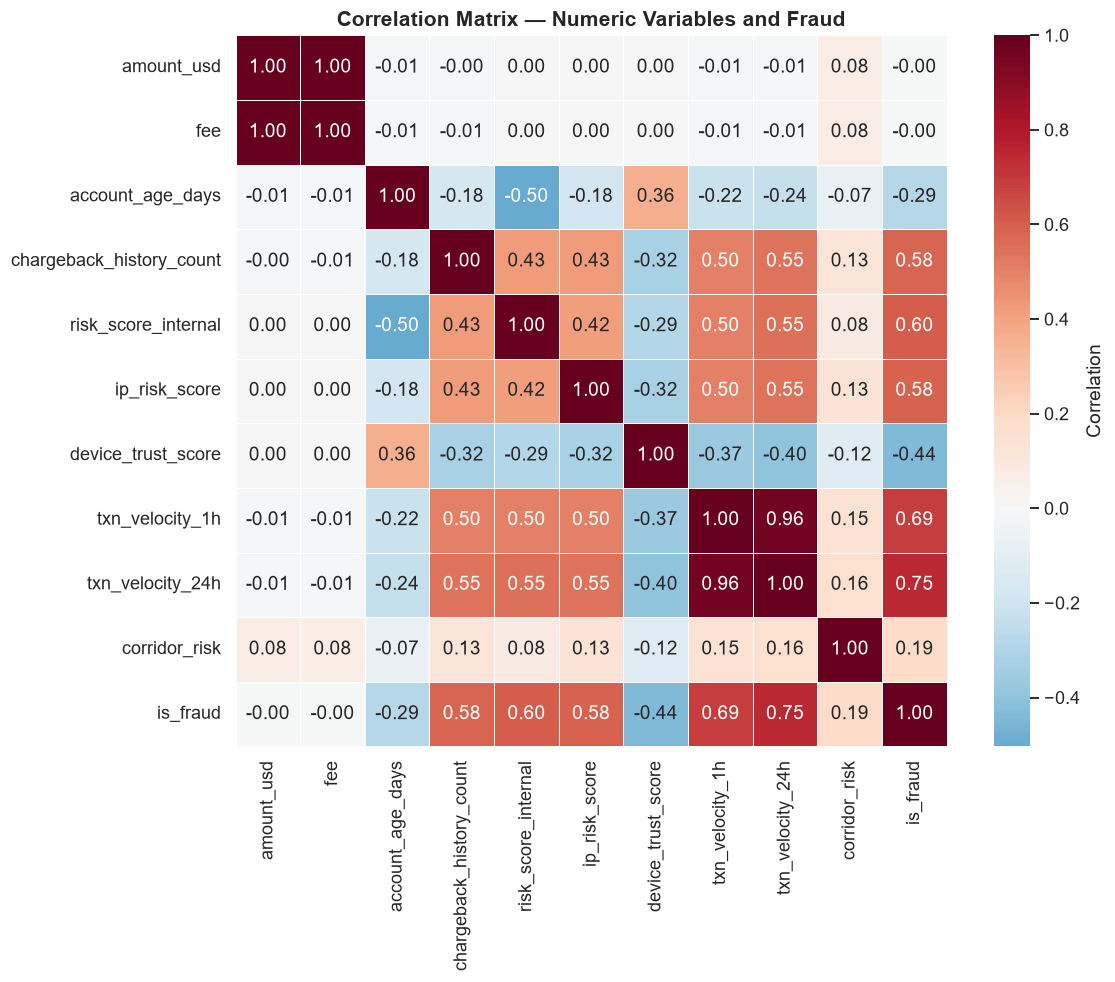

In [20]:
# ------------------------------------------------------------------
# Correlation heatmap across key numeric variables, including is_fraud
# ------------------------------------------------------------------
# Leakage-flagged variables are INCLUDED here deliberately, since this
# is a diagnostic view, but are labeled clearly in the write-up below.

corr_features = [
    "amount_usd", "fee", "account_age_days", "chargeback_history_count",
    "risk_score_internal", "ip_risk_score", "device_trust_score",
    "txn_velocity_1h", "txn_velocity_24h", "corridor_risk", "is_fraud"
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.title("Correlation Matrix — Numeric Variables and Fraud", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Finding: Correlation Matrix — Numeric Variables and Fraud

This heatmap confirms, with exact figures, the leakage concern first raised in
Data Profiling: `txn_velocity_24h` (0.75), `txn_velocity_1h` (0.69),
`risk_score_internal` (0.60), `chargeback_history_count` (0.58), `ip_risk_score`
(0.58), and `device_trust_score` (-0.44) all show correlations with `is_fraud`
far higher than typically expected of honest, pre-transaction fraud predictors.
This independent confirmation, arrived at through a different analytical pass,
strengthens the case that these variables require provenance resolution before
being used in modelling.

Two additional multicollinearity findings emerged from this view:

- **amount_usd and fee are perfectly correlated (r = 1.00).** This is partly a
  consequence of the fee-recovery method used in Data Cleaning (fee was
  reconstructed as ~2.07% of amount_usd for missing rows), but the two variables
  were already closely related beforehand. Including both as independent linear
  features would add little value over including one.
- **txn_velocity_1h and txn_velocity_24h are highly correlated (r = 0.96).**
  These should be treated as a single decision in Feature Engineering (include
  one, or neither) rather than two independent choices, given both are also
  independently flagged for leakage risk.

Notably, amount_usd and fee show almost no LINEAR correlation with is_fraud
(~0.00) in this matrix, despite Section 4's bivariate analysis showing fraud
transactions have a meaningfully higher median/mean amount. This is not a
contradiction — Pearson correlation captures linear association and can
understate a relationship driven by differences in central tendency across a
heavily right-skewed variable. The amount-fraud relationship remains valid; it
is simply not well captured by this particular statistic.

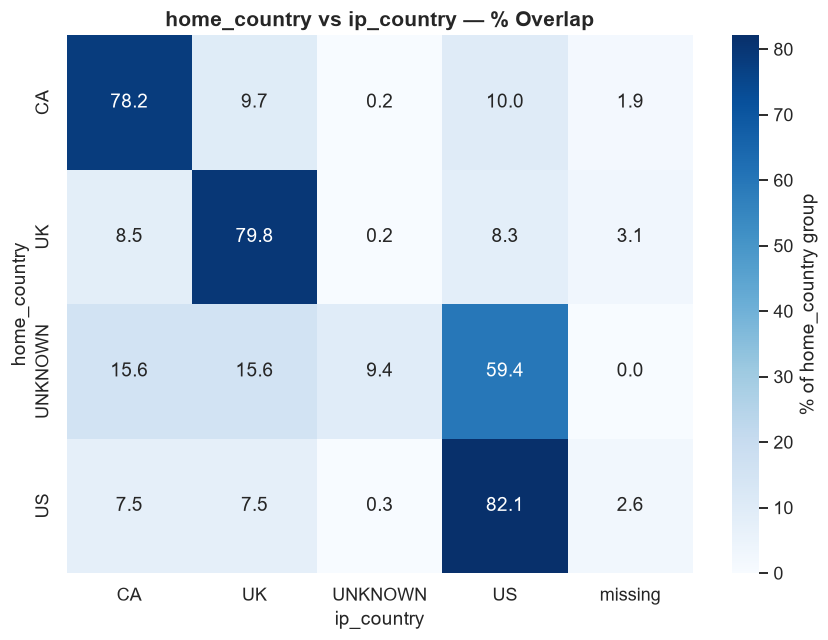

In [21]:
# ------------------------------------------------------------------
# Check overlap between home_country and ip_country signal
# (flagged as a potential multicollinearity concern in Section 9)
# ------------------------------------------------------------------
crosstab = pd.crosstab(df["home_country"], df["ip_country"], normalize="index") * 100

plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% of home_country group"})
plt.title("home_country vs ip_country — % Overlap", fontsize=14, fontweight="bold")
plt.xlabel("ip_country")
plt.ylabel("home_country")
plt.tight_layout()
plt.show()

### Finding: home_country vs ip_country Overlap

The diagonal of this crosstab dominates clearly: 78.2% of CA customers connect
from a CA IP, 79.8% of UK customers from a UK IP, and 82.1% of US customers from
a US IP. This confirms home_country and ip_country carry largely redundant
information for the three main countries in this dataset.

The one exception is the small `UNKNOWN` home_country group (n = 32), which
splits unevenly toward a US ip_country (59.4%) — however, given the very small
sample size, this should not be treated as a reliable pattern.

**Feature engineering implication:** rather than including both home_country and
ip_country as flat categorical features (which would largely duplicate each
other), it is more efficient to use one directly and derive additional signal
from where the two DISAGREE — which is effectively what the existing
location_mismatch column already captures.

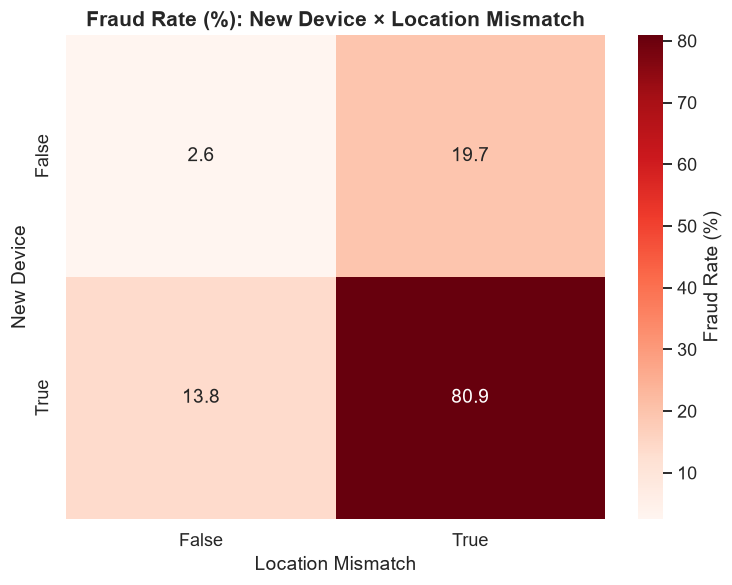

In [22]:
# ------------------------------------------------------------------
# Joint view: fraud rate by new_device AND location_mismatch together
# ------------------------------------------------------------------
joint_fraud = df.groupby(["new_device", "location_mismatch"])["is_fraud"].agg(["mean", "count"])
joint_fraud["fraud_rate_pct"] = joint_fraud["mean"] * 100
joint_pivot = joint_fraud["fraud_rate_pct"].unstack()

plt.figure(figsize=(7, 5.5))
sns.heatmap(joint_pivot, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "Fraud Rate (%)"})
plt.title("Fraud Rate (%): New Device × Location Mismatch", fontsize=14, fontweight="bold")
plt.xlabel("Location Mismatch")
plt.ylabel("New Device")
plt.tight_layout()
plt.show()

### Finding: New Device × Location Mismatch Interaction

This is one of the strongest and most useful patterns identified in the entire
EDA process. Fraud rate does not simply add up across the two risk factors —
it compounds sharply when both are present:

- Neither flag present: 2.6% fraud rate
- Location mismatch only: 13.8%
- New device only: 19.7%
- **Both new device AND location mismatch: 80.9%**

The jump to 80.9% is far larger than a simple additive combination of the two
individual effects would predict, indicating a genuine interaction effect rather
than two independent signals. Since neither new_device nor location_mismatch is
flagged for data leakage, this is a high-confidence, low-risk finding.

**Feature engineering implication:** construct an explicit interaction feature
(e.g. a combined flag or a 2x2 categorical) representing new_device AND
location_mismatch together, rather than relying on a model to discover this
interaction implicitly.

## EDA Summary and Feature Engineering Priorities

This notebook explored the cleaned FinLora transaction dataset across
univariate, bivariate, and multivariate views, in line with the project's EDA
requirements. The key takeaways are organized below by priority for the
upcoming Feature Engineering stage.

### High-confidence, low-risk features (recommended for direct use)
- **new_device**: 38.2% fraud rate vs. 4.9% for known devices
- **location_mismatch**: 36.0% vs. 3.6%
- **new_device x location_mismatch interaction**: 80.9% fraud rate when both are
  present, vs. 2.6% when neither is — the strongest safe signal found in this project
- **amount_usd**: consistently and meaningfully elevated for fraud across every
  cut of the data, despite a modest linear correlation coefficient
- **home_country / ip_country**: real geographic variation (CA > UK > US in both);
  the two variables are largely redundant with each other (75-82% overlap) and
  should not both be included as flat categorical features
- **customer transaction frequency (time-aware version only)**: one-time
  customers show a dramatically elevated fraud rate, but this MUST be
  reconstructed using point-in-time logic (transactions prior to the one being
  scored) per the leakage finding documented in Data Profiling — the naive
  full-history version is not safe to use

### High-risk features requiring provenance resolution before use
- **ip_risk_score, device_trust_score, txn_velocity_1h, txn_velocity_24h,
  risk_score_internal, chargeback_history_count**: each shows an unusually
  strong — in some cases near-deterministic — relationship with fraud (e.g. an
  84.9% fraud rate in the Critical device-trust tier, 67.5% in the Critical
  IP-risk tier). This strength is a warning sign rather than reassurance,
  consistent with concerns raised throughout Data Profiling and Data Cleaning.
  txn_velocity_1h and txn_velocity_24h are additionally near-duplicates of each
  other (r = 0.96) and should be treated as a single inclusion decision.
  Recommendation: build and compare model variants with and without this group
  of variables in Model Development, rather than deciding by default.

### Deprioritized
- Device- and IP-sharing-based features (e.g. device_customer_count): confirmed
  in Data Profiling to carry no signal in this dataset, since every device and
  IP maps to exactly one customer.

### Carried-forward observations (not resolved, flagged for awareness)
- kyc_tier missingness is itself informative (lower fraud rate than baseline)
  and should remain an explicit category rather than being imputed away.
- 11 customers show more than one recorded home_country across their
  transaction history; the cause is unexplained and was not corrected.